# DeepGuard — End-to-End Raw Video Inference Test

This notebook runs real-time deepfake inference on any **unseen video file** using trained DeepGuard models.

**Pipeline Architecture:**
Input Video → Even Frame Sampling → MTCNN Face Detection & Alignment → Pretrained Classifier Inference → Frame-by-Frame Confidence Plot → Aggregated Video Verdict.

In [3]:
# Install dependencies
!pip install -q -U torch torchvision opencv-python facenet-pytorch pillow matplotlib seaborn pandas

!pip install --upgrade --force-reinstall pillow torchvision

  Using cached pillow-12.3.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached torchvision-0.29.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.7 kB)
  Using cached torch-2.14.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.4.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached nvidia_cudnn_cu13-9.24.0.43-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (978 bytes)
  Using cached nvidia_cu

In [4]:
# Environment Setup and Imports
import os
import cv2
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from facenet_pytorch import MTCNN
from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")
if torch.cuda.is_available():
    print("GPU Model:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch Version: 2.14.0+cu130 | Active Device: cpu


In [5]:
# Global Configuration & Model Loader
IMAGE_SIZE = 224
FRAMES_TO_SAMPLE = 10
MIN_FACE_PROB = 0.90
FACE_PADDING = 0.15

PROJECT_DIR = Path("/content/drive/MyDrive/DeepGuard")
MODEL_SAVE_DIR = PROJECT_DIR / "trained_models"

# Initialize MTCNN for Face Detection
mtcnn = MTCNN(
    image_size=IMAGE_SIZE,
    margin=0,
    min_face_size=80,
    thresholds=[0.7, 0.8, 0.8],
    factor=0.709,
    post_process=False,
    keep_all=True,
    device=device
)

# Model Loader Utility
def load_classifier(architecture_name):
    weights_path = MODEL_SAVE_DIR / f"{architecture_name}_best.pth"
    if not weights_path.exists():
        raise FileNotFoundError(f"Model checkpoint missing: {weights_path}")

    if architecture_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    elif architecture_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 1)
    elif architecture_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    else:
        raise ValueError(f"Unsupported architecture: {architecture_name}")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Loaded {architecture_name.upper()} model weights successfully.")
    return model

# Image preprocessing transform for classifier
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
# Core Processing Helper Functions
def extract_sampled_frames(video_path, num_samples=FRAMES_TO_SAMPLE):
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Could not read video frames from: {video_path}")

    sample_indices = set(np.linspace(0, total_frames - 1, min(num_samples, total_frames), dtype=int))

    frames, indices = [], []
    curr_idx = 0
    while cap.isOpened() and len(frames) < len(sample_indices):
        ret, frame = cap.read()
        if not ret:
            break
        if curr_idx in sample_indices:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            indices.append(curr_idx)
        curr_idx += 1

    cap.release()
    return frames, indices

def crop_face(frame_rgb, boxes, probs):
    if boxes is None or probs is None:
        return None

    candidates = []
    for box, prob in zip(boxes, probs):
        if prob is not None and float(prob) >= MIN_FACE_PROB:
            x1, y1, x2, y2 = map(float, box)
            w, h = x2 - x1, y2 - y1
            if w > 0 and h > 0:
                candidates.append((x1, y1, x2, y2, w * h))

    if not candidates:
        return None

    # Crop largest face
    x1, y1, x2, y2, _ = max(candidates, key=lambda c: c[4])
    pad_x, pad_y = (x2 - x1) * FACE_PADDING, (y2 - y1) * FACE_PADDING

    x1 = max(0, int(x1 - pad_x))
    y1 = max(0, int(y1 - pad_y))
    x2 = min(frame_rgb.shape[1], int(x2 + pad_x))
    y2 = min(frame_rgb.shape[0], int(y2 + pad_y))

    crop = frame_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        return None

    return Image.fromarray(crop).resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)

In [12]:
# Inference Pipeline Function
def predict_video(video_path, architecture_name="resnet50"):
    print(f"""\n{'='*50}
Starting DeepGuard Inference Analysis
{'='*50}")
    print(f"Target Video: {video_path}""")

    # 1. Load Model
    model = load_classifier(architecture_name)

    # 2. Extract Frames
    raw_frames, frame_indices = extract_sampled_frames(video_path)
    print(f"Extracted {len(raw_frames)} frames for face detection.")

    # 3. Detect Faces
    boxes_batch, probs_batch = mtcnn.detect(raw_frames)

    face_crops, valid_indices = [], []
    for frame_rgb, idx, boxes, probs in zip(raw_frames, frame_indices, boxes_batch, probs_batch):
        crop = crop_face(frame_rgb, boxes, probs)
        if crop:
            face_crops.append(crop)
            valid_indices.append(idx)

    if not face_crops:
        print("ERROR: No valid faces detected in the video.")
        return None

    print(f"Successfully detected faces in {len(face_crops)} frames.")

    # 4. Batch Classifier Inference
    input_tensors = torch.stack([eval_transform(img) for img in face_crops]).to(device)

    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits = model(input_tensors)
            # Label 1 = REAL, Label 0 = FAKE
            real_probs = torch.sigmoid(logits).cpu().numpy().flatten()
            fake_probs = 1.0 - real_probs

    # 5. Aggregate Video Verdict
    mean_fake_prob = float(np.mean(fake_probs))
    mean_real_prob = float(np.mean(real_probs))
    verdict = "FAKE" if mean_fake_prob >= 0.5 else "REAL"
    confidence = mean_fake_prob if verdict == "FAKE" else mean_real_prob

    print(f"""\n{'*'*40}
FINAL VERDICT: Video is {verdict} ({confidence * 100:.2f}% Confidence)
{'*'*40}""")

    # 6. Plot Diagnostic Results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Timeline Confidence
    ax1.plot(valid_indices, fake_probs, marker='o', color='red' if verdict == "FAKE" else 'green', linewidth=2)
    ax1.axhline(0.5, color='gray', linestyle='--', label='Decision Threshold (0.5)')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel("Frame Index")
    ax1.set_ylabel("Deepfake Probability (Fake Score)")
    ax1.set_title("Frame-Level Deepfake Probability")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Display Sample Cropped Face
    ax2.imshow(face_crops[0])
    ax2.axis("off")
    ax2.set_title(f"Sample Face Input (Frame {valid_indices[0]})")

    plt.tight_layout()
    plt.show()

    return {
        "verdict": verdict,
        "confidence": confidence,
        "fake_score": mean_fake_prob,
        "real_score": mean_real_prob,
        "frame_fake_scores": fake_probs,
        "frame_indices": valid_indices
    }


Starting DeepGuard Inference Analysis
==================================================")
    print(f"Target Video: /content/drive/MyDrive/DeepGuard/test.mp4
Loaded RESNET50 model weights successfully.
Extracted 10 frames for face detection.
Successfully detected faces in 4 frames.

****************************************
FINAL VERDICT: Video is REAL (58.28% Confidence)
****************************************


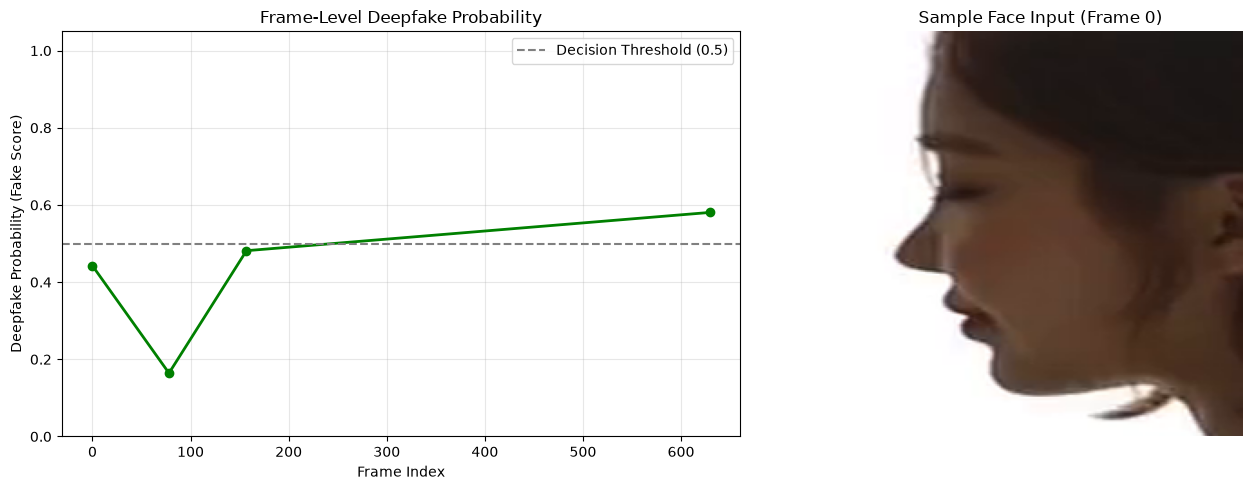

In [13]:
# Execute Inference Test
# Provide any MP4/AVI video path (e.g. uploaded directly or in Google Drive)
TEST_VIDEO_PATH = "/content/drive/MyDrive/DeepGuard/test.mp4"

# Select Architecture: 'resnet50', 'mobilenet_v2', or 'efficientnet_b0'
MODEL_TO_USE = "resnet50"

if os.path.exists(TEST_VIDEO_PATH):
    results = predict_video(TEST_VIDEO_PATH, architecture_name=MODEL_TO_USE)
else:
    print(f"File {TEST_VIDEO_PATH} not found. Please upload a test video to Colab or specify a valid Drive path.")